In [37]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler # PCA의 1단계(데이터 표준화) 를 자동으로 처리해주는 도구
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

In [3]:
# 데이터 로드
iris = load_iris()
X = iris.data  # X.shape하면 (150,4) 4차원으로 나옴

In [5]:
# 1. 표준화 (필수!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# 2. PCA (2차원으로 축소)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)  # X_pca.shape하면 (150,2) 2차원으로 나옴

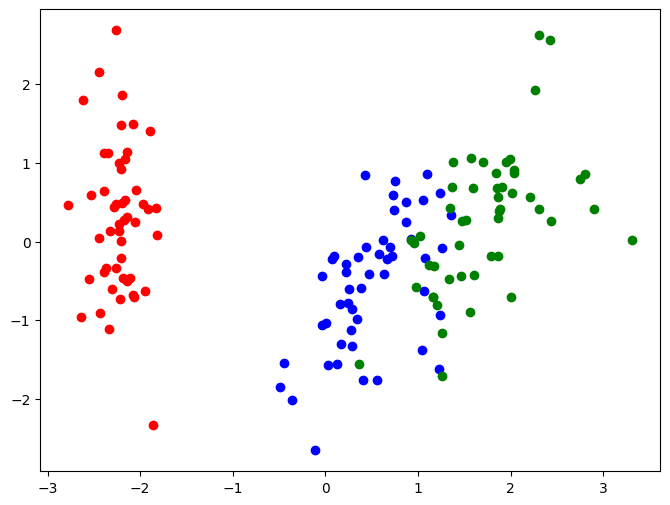

In [11]:
plt.figure(figsize=(8,6))
color = ['red','blue','green']

for i in range(3):
    mask = iris.target == i
    plt.scatter(X_pca[mask, 0], X_pca[mask,1], c=color[i])

In [22]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [23]:
# 데이터 생성
X, y_true = make_blobs(n_samples=300, centers=3,n_features=2, random_state=42)

In [24]:
X.shape

(300, 2)

In [25]:
# K-Means (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)  #cluster=3는 군집3개

In [28]:
y_true  # 실제값

array([2, 2, 0, 1, 2, 1, 0, 1, 0, 0, 0, 1, 0, 0, 2, 0, 2, 1, 0, 0, 0, 0,
       1, 2, 0, 2, 2, 1, 1, 0, 0, 0, 2, 0, 2, 0, 2, 1, 2, 1, 1, 0, 2, 1,
       0, 0, 2, 1, 2, 1, 1, 2, 2, 0, 2, 1, 2, 0, 1, 0, 2, 1, 1, 2, 2, 1,
       1, 2, 2, 0, 1, 2, 2, 0, 0, 2, 2, 1, 0, 1, 0, 0, 2, 0, 1, 2, 2, 0,
       1, 0, 2, 0, 2, 0, 0, 2, 2, 0, 2, 2, 1, 0, 1, 0, 0, 0, 0, 0, 1, 2,
       1, 0, 0, 0, 0, 1, 2, 1, 2, 1, 1, 1, 0, 2, 2, 2, 2, 0, 2, 2, 0, 0,
       0, 0, 0, 1, 1, 2, 0, 2, 0, 0, 2, 0, 1, 1, 1, 0, 1, 0, 0, 2, 1, 2,
       0, 1, 1, 2, 2, 0, 0, 2, 2, 2, 0, 2, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 2, 0, 2, 1, 1, 2, 1, 0, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1,
       0, 2, 0, 0, 1, 1, 0, 1, 2, 2, 1, 0, 0, 2, 1, 1, 2, 2, 2, 2, 0, 2,
       2, 1, 2, 2, 0, 1, 2, 2, 1, 0, 0, 2, 0, 2, 1, 1, 2, 1, 2, 2, 2, 1,
       1, 0, 2, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1, 0, 2, 0, 0, 0, 2, 0,
       1, 1, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 0, 0, 1, 1, 1, 1, 2, 1,
       2, 1, 1, 2, 0, 1, 1, 0, 2, 0, 1, 0, 2, 2])

In [27]:
kmeans.fit_predict(X) #  예측값

array([1, 1, 0, 2, 1, 2, 0, 2, 0, 0, 0, 2, 0, 0, 1, 0, 1, 2, 0, 0, 0, 0,
       2, 1, 0, 1, 1, 2, 2, 0, 0, 0, 1, 0, 1, 0, 1, 2, 1, 2, 2, 0, 1, 2,
       0, 0, 1, 2, 1, 2, 2, 1, 1, 0, 1, 2, 1, 0, 2, 0, 1, 2, 2, 1, 1, 2,
       2, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 2, 0, 2, 0, 0, 1, 0, 2, 1, 1, 0,
       2, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 2, 1,
       2, 0, 0, 0, 0, 2, 1, 2, 1, 2, 2, 2, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 2, 2, 1, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 2, 0, 0, 1, 2, 1,
       0, 2, 2, 1, 1, 0, 0, 1, 1, 1, 0, 1, 2, 0, 0, 0, 0, 0, 2, 0, 2, 2,
       2, 0, 2, 2, 1, 0, 1, 2, 2, 1, 2, 0, 2, 2, 1, 1, 2, 1, 2, 2, 2, 2,
       0, 1, 0, 0, 2, 2, 0, 2, 1, 1, 2, 0, 0, 1, 2, 2, 1, 1, 1, 1, 0, 1,
       1, 2, 1, 1, 0, 2, 1, 1, 2, 0, 0, 1, 0, 1, 2, 2, 1, 2, 1, 1, 1, 2,
       2, 0, 1, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 2, 0, 1, 0, 0, 0, 1, 0,
       2, 2, 1, 2, 2, 0, 0, 2, 2, 2, 1, 1, 1, 0, 0, 0, 2, 2, 2, 2, 1, 2,
       1, 2, 2, 1, 0, 2, 2, 0, 1, 0, 2, 0, 1, 1], d

In [59]:
print("클러스터 라벨:", labels[:10])
print("클러스터 중심:", kmeans.cluster_centers_)

클러스터 라벨: [0 0 0 0 0 0 0 0 0 0]
클러스터 중심: [[-3.52626744  8.96178646]
 [-6.7461045  -7.77009201]
 [ 5.1436098   2.87502743]
 [ 5.37610332  1.26853118]
 [-8.15072279 -6.60220424]
 [-2.49227813 10.51238696]
 [ 3.58706455  2.00396438]
 [-6.03417199 -5.96361058]
 [-2.31986779  7.93526396]
 [-1.74659164  9.39516061]]


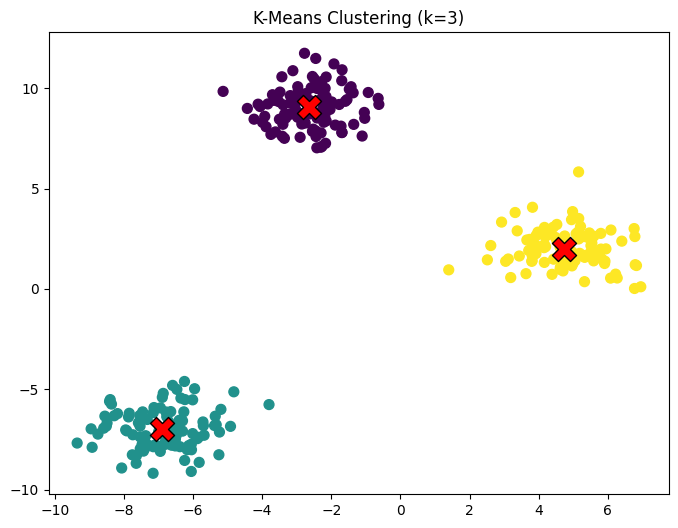

In [29]:
# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(x=X[:, 0], y=X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], 
           kmeans.cluster_centers_[:, 1],
           c='red', s=300, marker='X', edgecolors='black')
plt.title('K-Means Clustering (k=3)')
plt.show()
# c = kmeans.cluster_centers_ : kneans의 군집(cluster)행의 중점이 나옴
# cluster 잘된것 : 군집 안에 값은 모여있고 군집과 군집간의 거리는 먼것

In [ ]:
# c = kmeans.cluster_centers_ : kneans의 군집(cluster)행의 중점이 나옴
# cluster 잘되는건 군집 안에 값은 모여있고 군집과 군집간의 거리는 멀어야됨

In [60]:
inertias = []
silhouettes = []

for k in range(2,11):
    kmeans = KMeans(n_clusters= k, random_state=42)
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))

In [61]:
inertias

[380.57497333260704,
 32.43189392504041,
 27.26911468037386,
 21.887559794373274,
 18.825289028224976,
 14.60701304944182,
 10.685873372276935,
 8.618666019847764,
 5.534056240350609]

In [62]:
silhouettes

[0.6888255849702498,
 0.836036186340657,
 0.6282928039780483,
 0.4386845875836028,
 0.4690403201384565,
 0.3031562581474144,
 0.38636670892512914,
 0.4131009766926411,
 0.3609735751953662]

In [44]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt


In [51]:
# Hierarchical Clustering 실습 계층적 군집
# 데이터
X, y = make_blobs(n_samples=20, centers=3,n_features=2, random_state=42)
# centers 군집

In [52]:
X.shape

(20, 2)

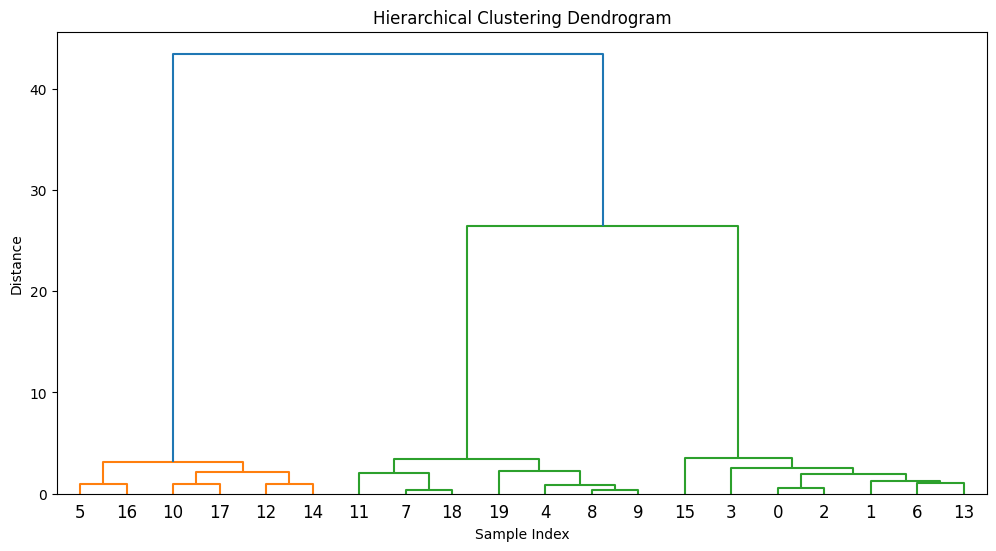

In [53]:
# 1. Dendrogram 그리기
Z = linkage(X, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

In [54]:
# 2. 군집화 (k=3)
clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = clustering.fit_predict(X)

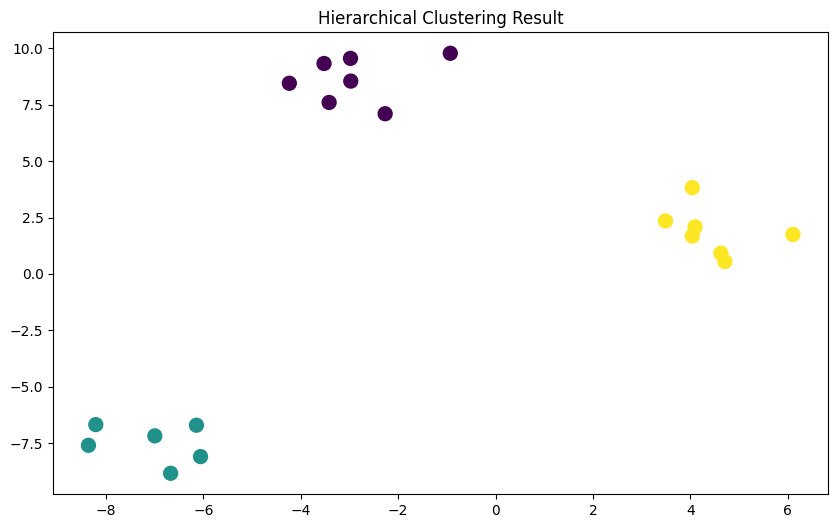

In [56]:
# 3. 시각화
plt.figure(figsize=(10, 6))
plt.scatter(x=X[:, 0], y=X[:, 1], c=labels, s=100, cmap='viridis')
plt.title('Hierarchical Clustering Result')
plt.show()

In [57]:
clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = clustering.fit_predict(X_pca)

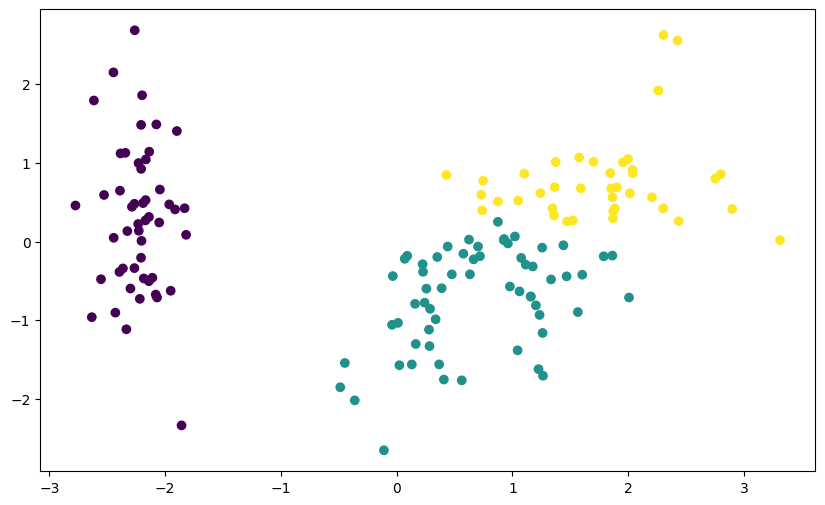

In [58]:
plt.figure(figsize=(10, 6))
plt.scatter(x=X_pca[:, 0], y=X_pca[:, 1], c=labels)
plt.show()